In [2]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
result = pd.read_csv('sample_submission.csv')

df = train.copy()
X_test = test.copy()


#Data Cleaning
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"{df.duplicated().sum()} removed")
else:
    print("No duplicates found")
if df.isnull().any().sum() > 0:
    print(f"There are {df.isnull().any().sum()} missing values in the dataset")
    df = df.dropna()
else:
    print("No missing values found")



No duplicates found
No missing values found


Boxplotting for outliers:


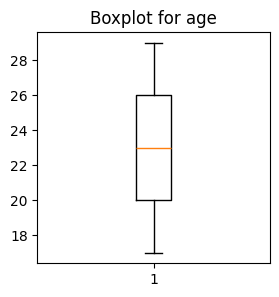

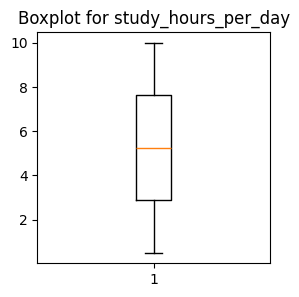

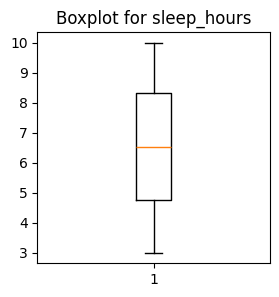

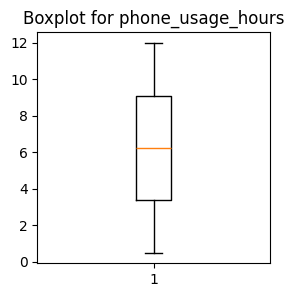

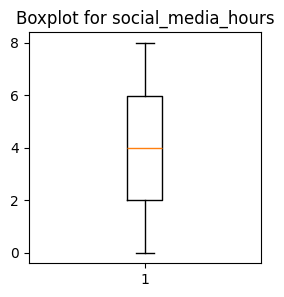

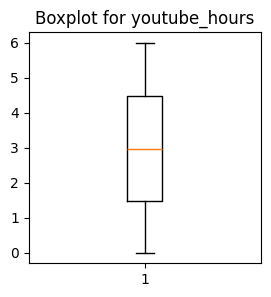

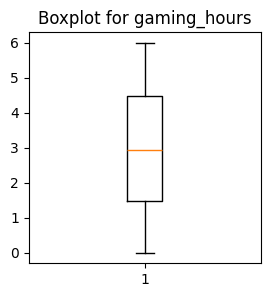

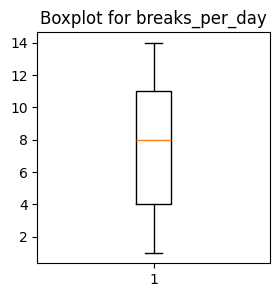

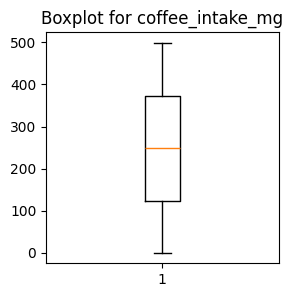

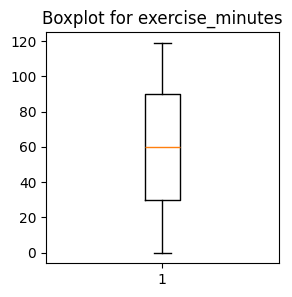

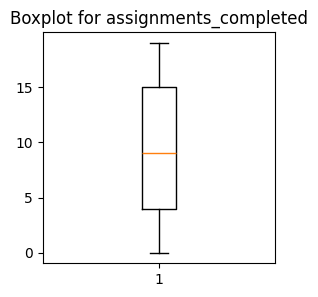

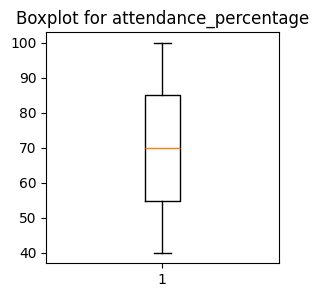

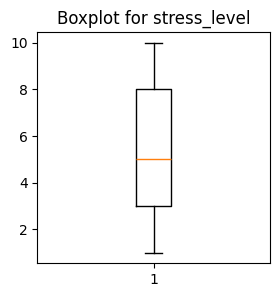

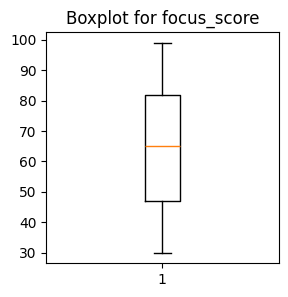

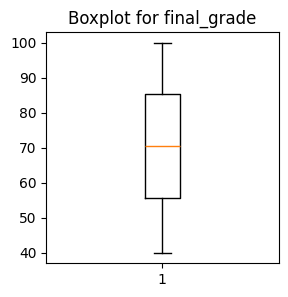

In [3]:
#Boxplotting for outliers:
import matplotlib.pyplot as plt
cols = ['age','study_hours_per_day','sleep_hours','phone_usage_hours','social_media_hours','youtube_hours','gaming_hours','breaks_per_day','coffee_intake_mg','exercise_minutes','assignments_completed','attendance_percentage','stress_level','focus_score', 'final_grade']
print('Boxplotting for outliers:')
for col in cols:
    plt.figure(figsize=(3, 3))
    plt.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show() 

Distribution check:


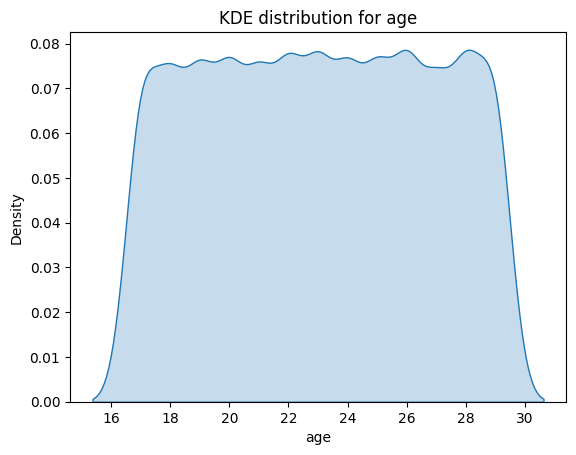

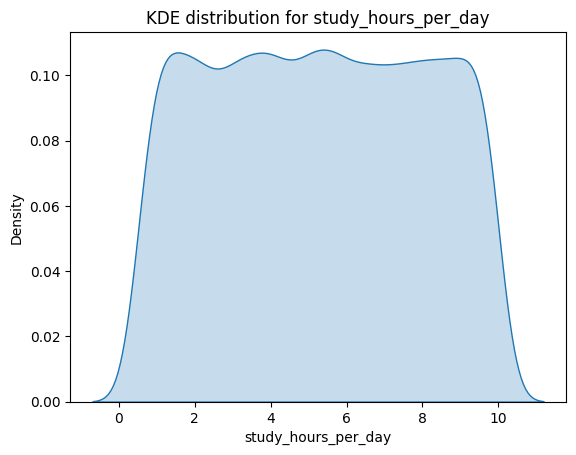

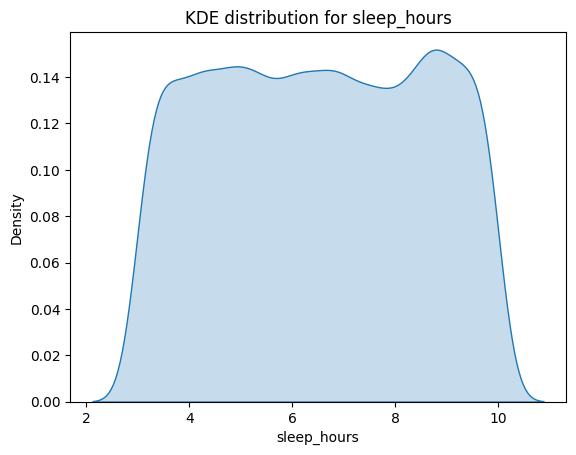

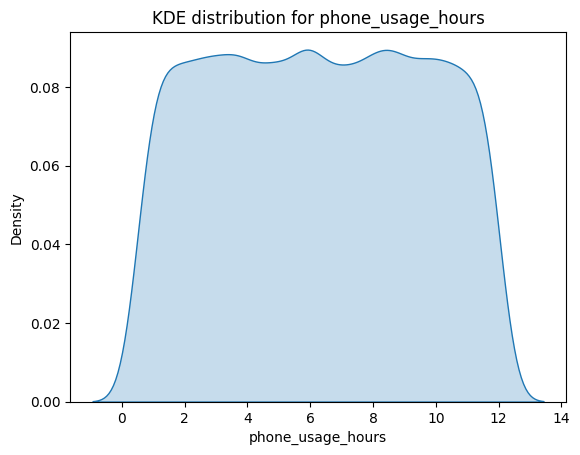

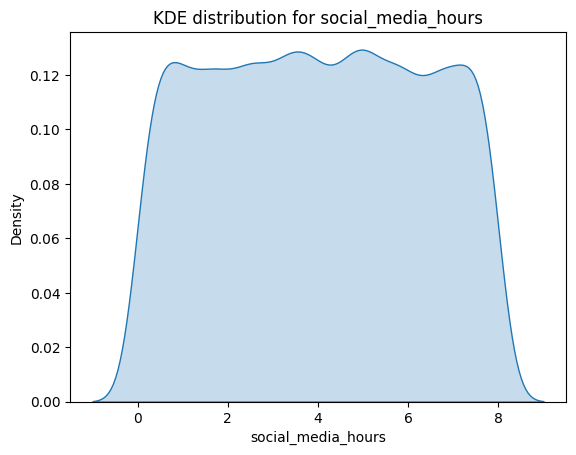

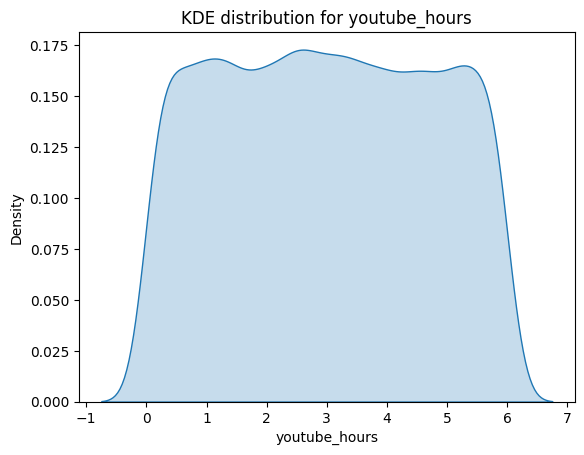

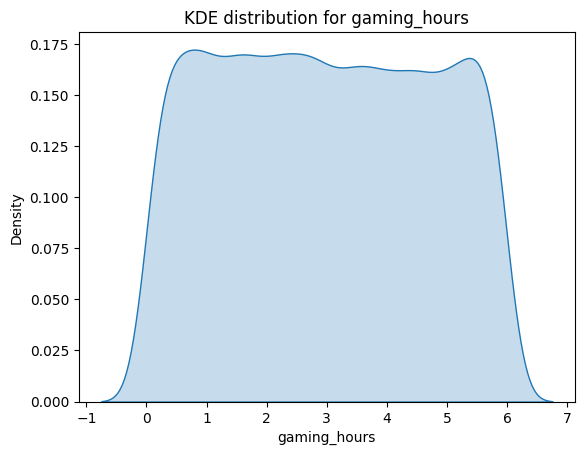

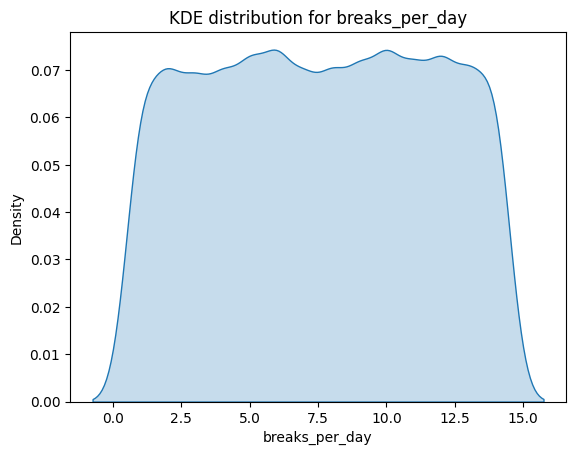

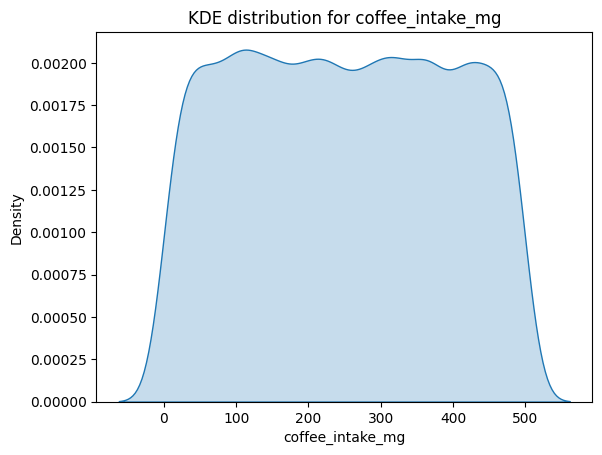

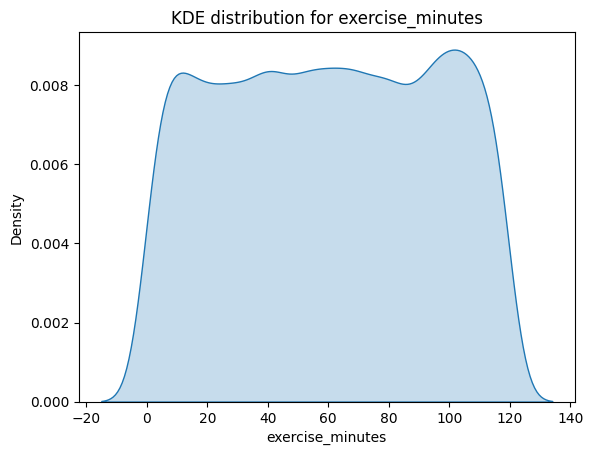

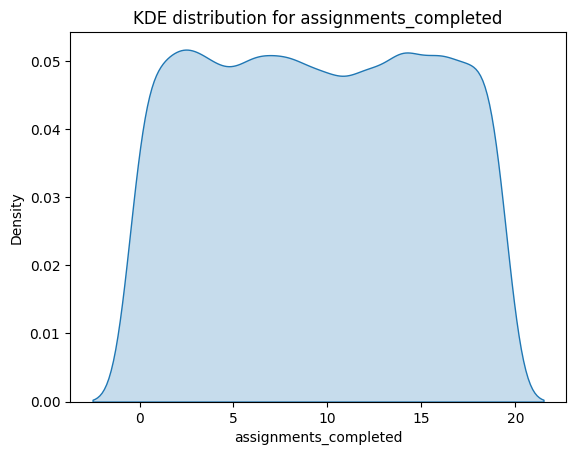

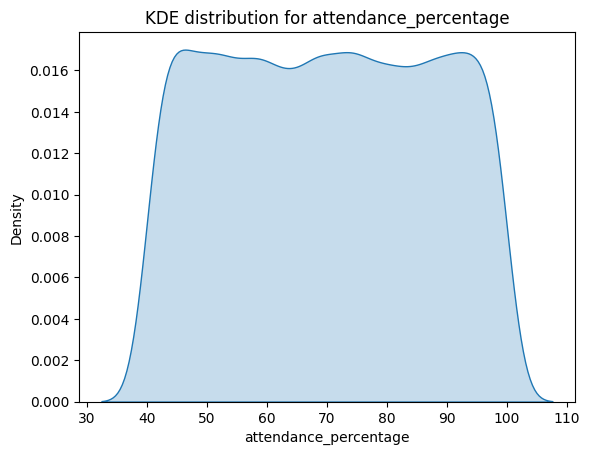

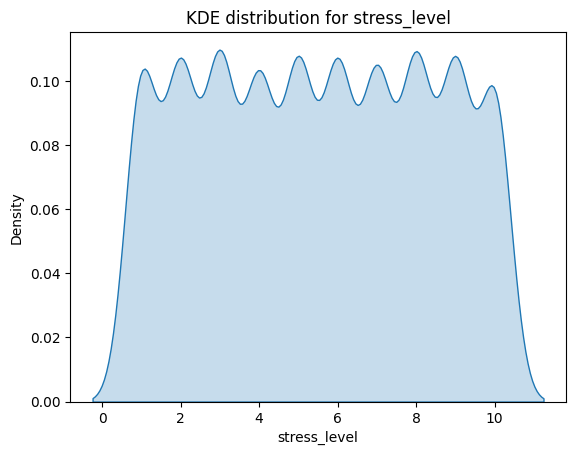

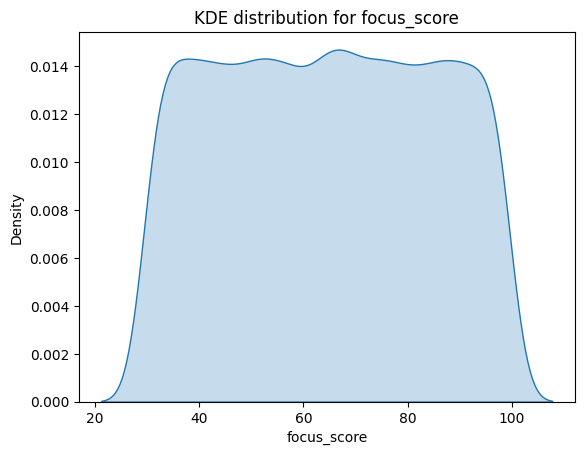

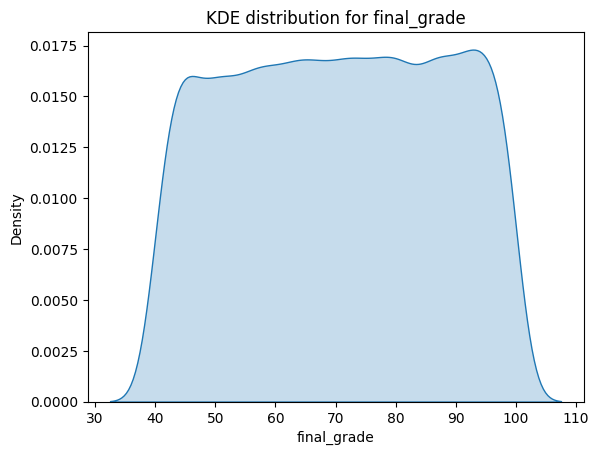

In [4]:
#Distribution check:
import seaborn as sns
import matplotlib.pyplot as plt
print('Distribution check:')
for col in cols:
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE distribution for {col}")
    plt.show()

In [5]:
#Encoding categorical variables:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_column = encoder.fit_transform(df[['gender']])
encoded_df = pd.DataFrame(
    encoded_column,
    columns=encoder.get_feature_names_out(["gender"])
)
df = pd.concat([df.reset_index(drop=True), encoded_df], axis=1)
df = df.drop(columns=['gender'])

encoded_column_test = encoder.fit_transform(X_test[['gender']])
encoded_test_dataset = pd.DataFrame(encoded_column_test, columns=encoder.get_feature_names_out(['gender']))
X_test = pd.concat([X_test, encoded_test_dataset], axis = 1)
X_test = X_test.drop(columns = ['gender'])


#Data splitting
Y_train = df['productivity_score']
X_train = df.drop(columns = ['productivity_score'])


In [6]:
# Drop irrelevant columns (id, student_id) and data leaking column (final_grade)
cols_to_drop = ['id', 'student_id', 'final_grade']

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

print("Columns after dropping:", X_train.columns.tolist())
print("X_train shape:", X_train.shape)

Columns after dropping: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'gender_Female', 'gender_Male', 'gender_Other']
X_train shape: (16000, 17)


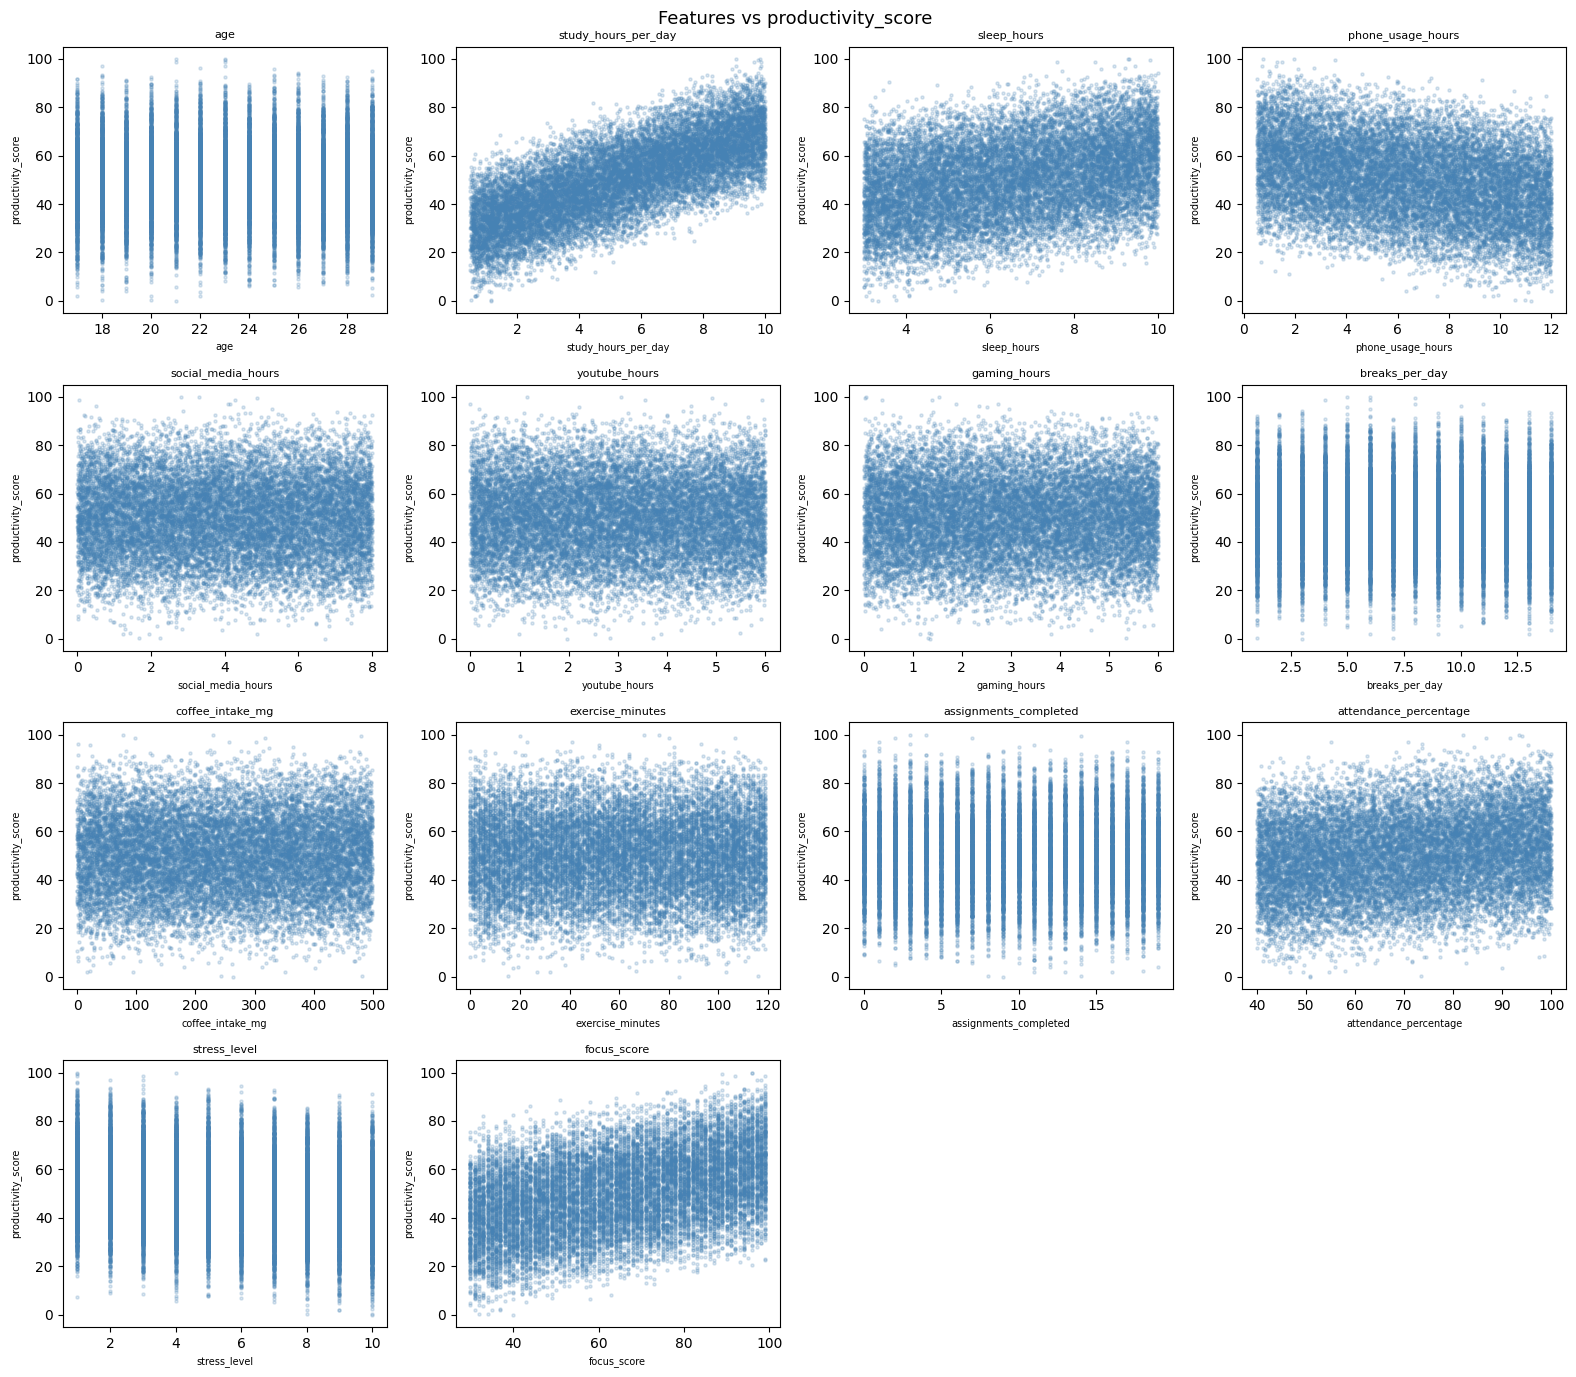

In [7]:
import matplotlib.pyplot as plt

# Scatter plots for relevant features vs target
cols = ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours',
        'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day',
        'coffee_intake_mg', 'exercise_minutes', 'assignments_completed',
        'attendance_percentage', 'stress_level', 'focus_score']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].scatter(X_train[col], Y_train, alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(col, fontsize=7)
    axes[i].set_ylabel('productivity_score', fontsize=7)
    axes[i].set_title(col, fontsize=8)

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Features vs productivity_score', fontsize=13)
plt.tight_layout()
plt.show()

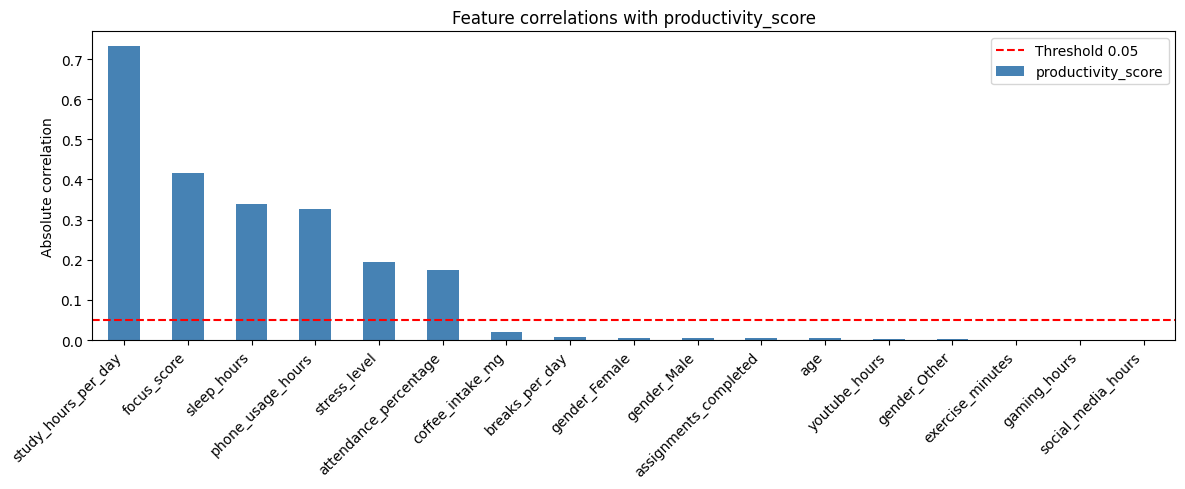

study_hours_per_day      0.732
focus_score              0.415
sleep_hours              0.339
phone_usage_hours        0.327
stress_level             0.196
attendance_percentage    0.175
coffee_intake_mg         0.020
breaks_per_day           0.007
gender_Female            0.006
gender_Male              0.005
assignments_completed    0.005
age                      0.004
youtube_hours            0.002
gender_Other             0.002
exercise_minutes         0.002
gaming_hours             0.001
social_media_hours       0.000
Name: productivity_score, dtype: float64


In [8]:
# Compute and plot correlation of each feature with the target
df_corr = X_train.copy()
df_corr['productivity_score'] = Y_train.values

correlation = df_corr.corr()['productivity_score'].drop('productivity_score')
correlation_sorted = correlation.abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
correlation_sorted.plot(kind='bar', color='steelblue')
plt.axhline(y=0.05, color='red', linestyle='--', label='Threshold 0.05')
plt.title('Feature correlations with productivity_score')
plt.ylabel('Absolute correlation')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print(correlation_sorted.round(3))

In [9]:
# Check for highly correlated features (redundancy check)
corr_matrix = X_train.corr().round(2)
print("Feature correlations:")
print(corr_matrix)

Feature correlations:
                        age  study_hours_per_day  sleep_hours  \
age                    1.00                 0.00         0.01   
study_hours_per_day    0.00                 1.00        -0.00   
sleep_hours            0.01                -0.00         1.00   
phone_usage_hours      0.01                 0.01         0.00   
social_media_hours     0.00                 0.01        -0.01   
youtube_hours          0.02                -0.00         0.01   
gaming_hours           0.00                -0.00         0.00   
breaks_per_day        -0.00                -0.01         0.00   
coffee_intake_mg       0.01                 0.01         0.00   
exercise_minutes      -0.00                 0.01         0.00   
assignments_completed -0.00                 0.01         0.00   
attendance_percentage -0.01                -0.01         0.00   
stress_level          -0.00                 0.00         0.00   
focus_score           -0.01                 0.01        -0.00   
gen

In [10]:
from sklearn.feature_selection import f_regression, SelectFwe

# Run F-Regression to find statistically significant features
f_stats, p_values = f_regression(X_train, Y_train)

# Show results
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Statistic': f_stats.round(3),
    'p-value': p_values.round(6),
    'Significant (p<=0.05)': p_values <= 0.05
}).sort_values('p-value')

print(feature_scores.to_string(index=False))

              Feature  F-Statistic  p-value  Significant (p<=0.05)
  study_hours_per_day    18500.002 0.000000                   True
          sleep_hours     2071.274 0.000000                   True
    phone_usage_hours     1913.822 0.000000                   True
          focus_score     3330.934 0.000000                   True
         stress_level      636.561 0.000000                   True
attendance_percentage      503.928 0.000000                   True
     coffee_intake_mg        6.122 0.013359                   True
       breaks_per_day        0.789 0.374357                  False
        gender_Female        0.592 0.441772                  False
          gender_Male        0.456 0.499367                  False
assignments_completed        0.380 0.537565                  False
                  age        0.318 0.572599                  False
        youtube_hours        0.063 0.801494                  False
         gender_Other        0.059 0.807426                  F

In [11]:
from sklearn.feature_selection import f_regression, SelectFwe
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# feature selection and scaling
pipeline = Pipeline([
    ('selector', SelectFwe(f_regression, alpha=0.05)),
    ('scaler', StandardScaler())
])

# Fit on train, transform both train and test
X_train_scaled = pipeline.fit_transform(X_train, Y_train)
X_test_scaled  = pipeline.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[
    pipeline.named_steps['selector'].get_support()
].tolist()

removed_features = X_train.columns[
    ~pipeline.named_steps['selector'].get_support()
].tolist()

print("KEPT features ({}):\n".format(len(selected_features)))
for f in selected_features:
    print("  +", f)

print("\nREMOVED features ({}):\n".format(len(removed_features)))
for f in removed_features:
    print("  -", f)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=selected_features)

print("\nX_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)

KEPT features (6):

  + study_hours_per_day
  + sleep_hours
  + phone_usage_hours
  + attendance_percentage
  + stress_level
  + focus_score

REMOVED features (11):

  - age
  - social_media_hours
  - youtube_hours
  - gaming_hours
  - breaks_per_day
  - coffee_intake_mg
  - exercise_minutes
  - assignments_completed
  - gender_Female
  - gender_Male
  - gender_Other

X_train_scaled shape: (16000, 6)
X_test_scaled shape:  (4000, 6)


In [12]:
# Final check
print()
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Y_train shape: ", Y_train.shape)
print()
print("Identical columns in train and test:",
      X_train_scaled.columns.tolist() == X_test_scaled.columns.tolist())
print()
print("Missing values in X_train_scaled:", X_train_scaled.isnull().sum().sum())
print("Missing values in X_test_scaled:", X_test_scaled.isnull().sum().sum())
print()
print("Final features used by the model:")
for col in X_train_scaled.columns:
    print("-", col)


X_train_scaled shape: (16000, 6)
X_test_scaled shape: (4000, 6)
Y_train shape:  (16000,)

Identical columns in train and test: True

Missing values in X_train_scaled: 0
Missing values in X_test_scaled: 0

Final features used by the model:
- study_hours_per_day
- sleep_hours
- phone_usage_hours
- attendance_percentage
- stress_level
- focus_score


In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train-validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, Y_train, test_size=0.2, random_state=42
)

# Baseline KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_tr, y_tr)

# Predictions on validation set
y_pred = knn_model.predict(X_val)

# Evaluation metrics
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("Baseline KNN Results:")
print("MAE =", round(mae, 4))
print("MSE =", round(mse, 4))
print("RMSE =", round(rmse, 4))
print("R2 =", round(r2, 4))

Baseline KNN Results:
MAE = 1.9005
MSE = 5.709
RMSE = 2.3894
R2 = 0.9783


In [16]:
best_k = None
best_mse = float("inf")

print("KNN tuning results:")
for k in [3, 5, 7, 9, 11, 13]:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    mse_k = mean_squared_error(y_val, pred)
    print(f"k={k}, MSE={mse_k:.4f}")
    
    if mse_k < best_mse:
        best_mse = mse_k
        best_k = k

print("\nBest k found:", best_k)
print("Best validation MSE:", round(best_mse, 4))

KNN tuning results:
k=3, MSE=6.8892
k=5, MSE=5.7090
k=7, MSE=5.1323
k=9, MSE=4.9077
k=11, MSE=4.7463
k=13, MSE=4.7467

Best k found: 11
Best validation MSE: 4.7463


In [17]:
final_knn_model = KNeighborsRegressor(n_neighbors=best_k)
final_knn_model.fit(X_train_scaled, Y_train)

test_predictions = final_knn_model.predict(X_test_scaled)

result['productivity_score'] = test_predictions
result.to_csv('submission_knn.csv', index=False)

print("Submission saved successfully!")
print(result.head())

print()
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Y_train shape:", Y_train.shape)

print()
print("Identical columns in train and test:",
      X_train_scaled.columns.tolist() == X_test_scaled.columns.tolist())

print()
print("Missing values in X_train_scaled:", X_train_scaled.isnull().sum().sum())
print("Missing values in X_test_scaled:", X_test_scaled.isnull().sum().sum())

Submission saved successfully!
      id  productivity_score
0  10650           50.301818
1   2041           89.289091
2   8668           60.739091
3   1114           50.414545
4  13902           35.793636

X_train_scaled shape: (16000, 6)
X_test_scaled shape: (4000, 6)
Y_train shape: (16000,)

Identical columns in train and test: True

Missing values in X_train_scaled: 0
Missing values in X_test_scaled: 0
